<a href="https://colab.research.google.com/github/venkatbuilds/2d-game-transformation-engine/blob/main/sample8_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


========== 2D GAME TRANSFORMATION ENGINE ==========

Scaling Matrix S:
[[2. 0. 0.]
 [0. 2. 0.]
 [0. 0. 1.]]

Rotation Matrix R:
[[ 0.707 -0.707  0.   ]
 [ 0.707  0.707  0.   ]
 [ 0.     0.     1.   ]]

Translation Matrix T:
[[1. 0. 3.]
 [0. 1. 2.]
 [0. 0. 1.]]

Combined Matrix T × R × S:
[[ 1.414 -1.414  3.   ]
 [ 1.414  1.414  2.   ]
 [ 0.     0.     1.   ]]

Original Triangle:
Point A = (0.00, 0.00)
Point B = (2.00, 0.00)
Point C = (1.00, 2.00)

After Scaling:
Point A = (0.00, 0.00)
Point B = (4.00, 0.00)
Point C = (2.00, 4.00)

After Rotation:
Point A = (0.00, 0.00)
Point B = (2.83, 2.83)
Point C = (-1.41, 4.24)

After Translation:
Point A = (3.00, 2.00)
Point B = (5.83, 4.83)
Point C = (1.59, 6.24)


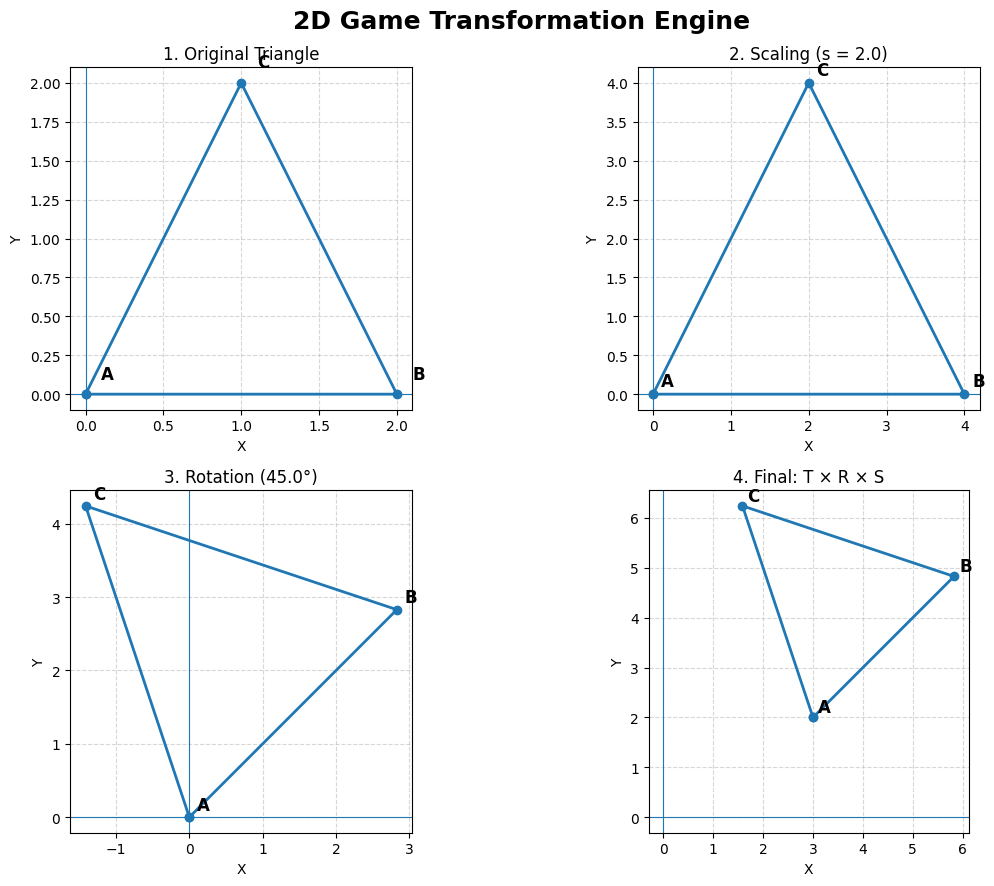


VERIFICATION
✓ Step-by-step result = Combined matrix result
✓ Transformation composition is correct!

Project completed successfully!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import radians, cos, sin

# ==========================================
# 2D GAME TRANSFORMATION ENGINE (F3)
# ==========================================

# ---------- USER INPUTS ----------
scale = 2.0
angle = 45.0
tx = 3.0
ty = 2.0

# ---------- ORIGINAL TRIANGLE ----------
# Homogeneous coordinates: [x, y, 1]
triangle = np.array([
    [0, 0, 1],   # A
    [2, 0, 1],   # B
    [1, 2, 1]    # C
]).T

# ---------- SCALING MATRIX ----------
S = np.array([
    [scale, 0, 0],
    [0, scale, 0],
    [0, 0, 1]
])

# ---------- ROTATION MATRIX ----------
theta = radians(angle)

R = np.array([
    [cos(theta), -sin(theta), 0],
    [sin(theta),  cos(theta), 0],
    [0,           0,          1]
])

# ---------- TRANSLATION MATRIX ----------
T = np.array([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1]
])

# ---------- STEP-BY-STEP TRANSFORMATIONS ----------

# 1. Scaling
scaled = S @ triangle

# 2. Rotation
rotated = R @ scaled

# 3. Translation
translated = T @ rotated

# ---------- COMBINED TRANSFORMATION ----------
# Total = Translation × Rotation × Scaling
Total = T @ R @ S

# Apply combined matrix
final_triangle = Total @ triangle

# ---------- PRINT MATRICES ----------
print("\n========== 2D GAME TRANSFORMATION ENGINE ==========")

print("\nScaling Matrix S:")
print(np.round(S, 3))

print("\nRotation Matrix R:")
print(np.round(R, 3))

print("\nTranslation Matrix T:")
print(np.round(T, 3))

print("\nCombined Matrix T × R × S:")
print(np.round(Total, 3))

# ---------- PRINT COORDINATES ----------
def print_points(name, points):
    print(f"\n{name}:")
    for i in range(3):
        print(
            f"Point {chr(65+i)} = "
            f"({points[0,i]:.2f}, {points[1,i]:.2f})"
        )

print_points("Original Triangle", triangle)
print_points("After Scaling", scaled)
print_points("After Rotation", rotated)
print_points("After Translation", translated)

# ---------- VISUALIZATION ----------

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle(
    "2D Game Transformation Engine",
    fontsize=18,
    fontweight="bold"
)

# Function to draw triangle
def draw_triangle(ax, points, title):
    x = list(points[0]) + [points[0, 0]]
    y = list(points[1]) + [points[1, 0]]

    ax.plot(x, y, marker="o", linewidth=2)

    for i, label in enumerate(["A", "B", "C"]):
        ax.text(
            points[0, i] + 0.1,
            points[1, i] + 0.1,
            label,
            fontsize=12,
            fontweight="bold"
        )

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.grid(True, linestyle="--", alpha=0.5)

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect("equal", adjustable="box")

# Original
draw_triangle(
    axes[0, 0],
    triangle,
    "1. Original Triangle"
)

# Scaled
draw_triangle(
    axes[0, 1],
    scaled,
    f"2. Scaling (s = {scale})"
)

# Rotated
draw_triangle(
    axes[1, 0],
    rotated,
    f"3. Rotation ({angle}°)"
)

# Final
draw_triangle(
    axes[1, 1],
    final_triangle,
    f"4. Final: T × R × S"
)

plt.tight_layout()
plt.show()

# ---------- VERIFICATION ----------
difference = np.max(np.abs(translated - final_triangle))

print("\n==============================================")
print("VERIFICATION")
print("==============================================")

if difference < 1e-10:
    print("✓ Step-by-step result = Combined matrix result")
    print("✓ Transformation composition is correct!")
else:
    print("✗ Something went wrong.")

print("\nProject completed successfully!")